# Aula 7: X do SARIMAX, Auto ARIMA

In [2]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
from funcoes import all_ac, plot_forecast, teste_estacionariedade, diagnostico, compara_previsoes
plt.rcParams["figure.figsize"] = [12, 5]
from statsmodels.tsa.statespace.sarimax import SARIMAX



In [3]:
df = pd.read_csv('/Users/danielferreira/Documents/git/classes/ASN/Séries Temporais/dados/clicks_original.csv')
df.index = pd.to_datetime(df['date'])
df = df.drop(['date'], axis=1)
df

/var/folders/f1/tdh3lyp114g78tg5wv2t7g3m0000gn/T/ipykernel_20818/3641001437.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df['date'])


,price,location,clicks
date,,,
2008-04-01,43.155647,2,18784
2008-04-02,43.079056,1,24738
2008-04-03,43.842609,2,15209
2008-04-04,43.312376,1,14018
2008-04-05,43.941176,1,11974
...,...,...,...
2008-08-09,44.182033,1,6716
2008-08-10,43.608260,1,9523
2008-08-11,43.553363,1,8881


In [5]:
model2 = SARIMAX(df['clicks'], order = (0,1,1), seasonal_order=(0,1,1,12), exog=df['price']).fit()

/Users/danielferreira/miniconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/danielferreira/miniconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            4     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  9.19475D+00    |proj g|=  2.01375D-01

At iterate    5    f=  9.09862D+00    |proj g|=  1.98466D-03

At iterate   10    f=  9.09861D+00    |proj g|=  9.59789D-04

At iterate   15    f=  9.09805D+00    |proj g|=  1.22817D-02

At iterate   20    f=  9.00731D+00    |proj g|=  3.99120D-02

At iterate   25    f=  8.96619D+00    |proj g|=  3.53490D-03

At iterate   30    f=  8.96590D+00    |proj g|=  6.34229D-05

At iterate   35    f=  8.96570D+00    |proj g|=  2.27777D-03

At iterate   40    f=  8.95263D+00    |proj g|=  8.46161D-03

At iterate   45    f=  8.91506D+00    |proj g|=  5.33102D-03

At iterate   50    f=  8.90710D+00    |proj g|=  2.38958D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cau

/Users/danielferreira/miniconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [6]:
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                             clicks   No. Observations:                  135
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1202.459
Date:                            Wed, 12 Mar 2025   AIC                           2412.917
Time:                                    22:32:11   BIC                           2424.134
Sample:                                04-01-2008   HQIC                          2417.473
                                     - 08-13-2008                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
price        243.5638     67.515      3.608      0.000     111.237     375.891
ma.L1         -0.9118      0.049    -18.666      0.000      -1.008      -0.816
ma.S.L12      -0.7856      0.120     -6.567      0.000      -1.020      -0.551
sigma2      2.028e+07      0.001    2.5e+10      0.000    2.03e+07    2.03e+07
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                83.32
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.26   Skew:                             1.15
Prob(H) (two-sided):                  0.47   Kurtosis:                         6.33
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.48e+25. Standard errors may be unstable.
"""

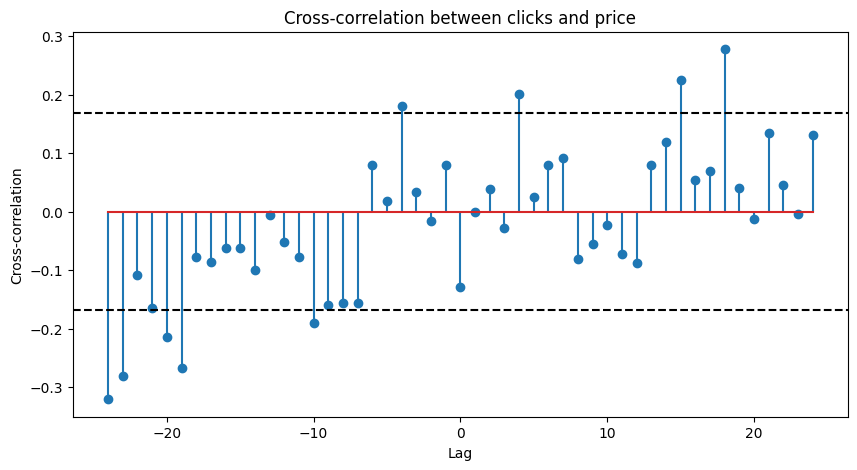

In [8]:
from statsmodels.tsa.stattools import ccf

y = df['clicks']
x = df['price']
cross_corr = ccf(y, x, nlags=25)
max_lag = 24
correlations = []
lags = range(-max_lag, max_lag + 1)

for l in lags:
    c = y.corr(x.shift(l))
    correlations.append(c)

plt.figure(figsize=(10, 5))
plt.stem(lags, correlations)
plt.xlabel('Lag')
plt.ylabel('Cross-correlation')
plt.title('Cross-correlation between clicks and price')
conf_interval = 1.96 / np.sqrt(len(df))
plt.axhline(-conf_interval, color='k', ls='--')
plt.axhline(conf_interval, color='k', ls='--')
plt.show()